<a href="https://colab.research.google.com/github/abdulrahman0700/intern_FlyRank_ai/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/abdulrahman0700/intern_FlyRank_ai/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Frame (filled per `skills/framing-ml-problems/SKILL.md`):**

> For **content strategists / editors at a FlyRank client**, deciding **which pages to invest limited editing/optimization time in next**, we will build **a ranked opportunity score** from **the anonymized content-refresh feature set**, predicting/scoring **expected performance upside per page** measured by **projected traffic/click gain (or a proxy such as impression-to-click headroom) captured in a later time window**. A wrong call costs **editor hours spent on pages that were never going to move, and real upside left on pages that get ignored**. A plain rule (e.g. "fix anything below position 10") isn't enough because **impact is driven by an interaction of several signals — current position, impression volume, CTR gap vs. expected, content age/freshness — that a single threshold can't weigh correctly**. We will claim only **directional / decision-support** results — this ranks *where to look first*, it does not predict Google's algorithm or guarantee traffic gains.

**Why this differs from the reference "fix this page" framing:** the default pipeline scores *risk/decline* (which pages are broken). Opportunity modeling instead scores *upside* (which pages, if improved, would likely move the needle most) — same dataset, a different target and a different action for the editor.

**Open items to confirm against `docs/data-dictionary.md` before moving to Section 3:**
- [ ] Which column(s) give a genuine, *observed* outcome to train/evaluate against (not something engineered from the same row we're scoring) — avoids the "predicted risk of decline" leakage trap called out in the framing skill.
- [ ] Whether "expected impact" should be defined as a business proxy (e.g. estimated click delta from moving up N positions, weighted by impression volume) rather than a raw column, and if so, that proxy needs its own formula documented in Section 3.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

- **Source / release:** `data/raw/content_refresh_anonymized.csv` from the FlyRank ML Internship starter repo (`flyrank-bih/flyrank-ml-internship-starter`) — the anonymized starter slice (~30,000 rows, 44 columns per `docs/data-dictionary.md`).
- **Anonymization:** no client names, domains, URLs, titles, or keywords are present in this file (see `DATA_USE.md`); nothing in this notebook re-identifies or attempts to re-identify any client.
- **Date window:** *(fill in from the data dictionary / a `.describe()` on the relevant date column — e.g. "GSC metrics cover the trailing N days as of the anonymized export date.")*
- **Unit of analysis:** one row = one anonymized page.
- **Exclusions:** *(record here anything you drop — e.g. rows with insufficient impression volume to trust a CTR-based signal, or rows missing the outcome window — and why)*.
- **What this data does NOT license:** claims about Google's ranking algorithm itself. All outputs are framed as observed / measured / directional / decision-support, never predictive of the algorithm.


In [10]:
import pandas as pd

# Starter dataset (public-safe, anonymized) — see docs/data-dictionary.md for the 44-column schema
DATA_PATH = "/content/content_refresh_anonymized.csv"

df = pd.read_csv(DATA_PATH)

print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")
print()
print("Columns:")
print(list(df.columns))
print()
print("Nulls per column (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))
print()
# TODO once the date/outcome-window column is confirmed against the data dictionary:
# print("Date range:", df[<date_col>].min(), "to", df[<date_col>].max())


Rows: 30,000 | Columns: 44

Columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']

Nulls per column (top 10):
provider_used        21438
word_count            7699
char_count            7699
word_count_tier       7699
char_count_tier       7699
model_used            5733
tr

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Label (target):**

> `impact_pct = (clicks_last_30d - clicks_prev_30d) / clicks_prev_30d`

An observed, backward-looking outcome — the actual click change between two real 30-day windows for each page. Not a rule we invented; it's measured directly from the data.

**Features (inputs)** — drawn only from the `_prev_30d` window or earlier:
- `impressions_prev_30d`
- `clicks_prev_30d`
- `sessions_prev_30d`
- `ctr_prev_30d` (derived: `clicks_prev_30d / impressions_prev_30d`, *not* the raw `ctr` column)
- `search_volume`
- `content_type`
- *(add `cpc` / `engagement_rate` here only once their time window is confirmed against the data dictionary; otherwise they stay excluded below)*

**Excluded as leakage risk:**
- `impressions_last_30d`, `clicks_last_30d`, `sessions_last_30d` — these are consumed by the label itself and cannot also be features.
- Raw `ctr`, `engagement_rate`, `cpc` — excluded unless/until confirmed to be computed over the `_prev_30d` window or earlier.

**Baseline (hand rule, no model):**

> `baseline_score = search_volume_prev_30d * (1 - ctr_prev_30d)`

Rank pages descending by this score. Computed and recorded *before* any model is trained — this is what the trained model has to beat in Section 4.

**Validation design:**
- Split by `client_id` (not by random row) — holdout a subset of clients entirely so the model is evaluated on clients it never trained on.
- Split ratio and random seed: *(fill in once finalized, e.g. 80/20 clients, seed=42)*.

**Leakage check:**
Every feature above is drawn from the `_prev_30d` window or earlier; the label is drawn from `_last_30d` vs `_prev_30d`. No feature is mathematically derived from `_last_30d` columns or from the label itself.

**Assumptions:**
1. The anonymized sample is representative enough of the broader client base for directional conclusions.
2. `search_volume` is treated as a stable external signal unaffected by the page's own recent performance.
3. *(add any additional assumption specific to your final feature set)*


In [11]:
import pandas as pd

# --- Label ---
df["impact_pct"] = (df["clicks_last_30d"] - df["clicks_prev_30d"]) / df["clicks_prev_30d"]

# --- Derived, leakage-safe feature ---
df["ctr_prev_30d"] = df["clicks_prev_30d"] / df["impressions_prev_30d"]

FEATURES = [
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "ctr_prev_30d",
    "search_volume",
    "content_type",
]
LABEL = "impact_pct"

EXCLUDED_LEAKAGE_RISK = [
    "impressions_last_30d", "clicks_last_30d", "sessions_last_30d",  # consumed by label
    "ctr", "engagement_rate", "cpc",  # time window unconfirmed
]

print("Features:", FEATURES)
print("Label:", LABEL)
print("Excluded (leakage risk / unconfirmed window):", EXCLUDED_LEAKAGE_RISK)
print()
print(df[FEATURES + [LABEL]].describe())

# --- Baseline (hand rule, no model) ---
df["baseline_score"] = df["search_volume"] * (1 - df["ctr_prev_30d"])
baseline_ranked = df.sort_values("baseline_score", ascending=False)
print()
print("Top 5 by baseline_score:")
print(baseline_ranked[["baseline_score", "impact_pct"]].head())

# --- Validation split (by client, not by row) ---
# TODO: confirm the client id column name against docs/data-dictionary.md
CLIENT_COL = "client_id"
clients = df[CLIENT_COL].unique()
# holdout ~20% of clients
import numpy as np
rng = np.random.default_rng(42)
holdout_clients = rng.choice(clients, size=int(len(clients) * 0.2), replace=False)

train_df = df[~df[CLIENT_COL].isin(holdout_clients)]
test_df = df[df[CLIENT_COL].isin(holdout_clients)]
print()
print(f"Train rows: {len(train_df):,} | Test rows: {len(test_df):,} | Holdout clients: {len(holdout_clients)}")


Features: ['impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'ctr_prev_30d', 'search_volume', 'content_type']
Label: impact_pct
Excluded (leakage risk / unconfirmed window): ['impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'ctr', 'engagement_rate', 'cpc']

       impressions_prev_30d  clicks_prev_30d  sessions_prev_30d  ctr_prev_30d  \
count          30000.000000     30000.000000       30000.000000  26612.000000   
mean            1783.078500         5.435100          10.283000      0.004355   
std             6150.429511        28.358673          42.578003      0.037013   
min                0.000000         0.000000           0.000000      0.000000   
25%               19.000000         0.000000           1.000000      0.000000   
50%              210.000000         0.000000           2.000000      0.000000   
75%             1143.000000         2.000000           7.000000      0.002551   
max           218786.000000      1627.000000        4247.000000  

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

**Metric:** Precision@50 — of the top 50 ranked pages, what fraction actually had positive `impact_pct` in the holdout window. (Swap for Spearman correlation or NDCG if a ranking-quality metric fits your write-up better — just use the *same* metric for both rows below.)

| | Precision@50 | Notes |
|---|---|---|
| Baseline (`baseline_score` rule) | *(fill in from code output)* | Hand rule, no model, computed in Section 3 |
| Model | *(fill in from code output)* | Trained on `train_df`, evaluated on held-out clients |

**Stable claim:** report the *relative lift* over baseline (e.g. "~Nx over baseline") as the headline number — per the starter repo's own guidance, the exact third decimal is library-version sensitive; the lift is what should be reproducible.

**Sanity check before trusting this table:** if the model's Precision@50 looks suspiciously close to 1.0, stop and re-check the Section 3 leakage list — that's usually a sign a `_last_30d` column slipped into the features.


In [12]:
import pandas as pd
import numpy as np # Import numpy for np.inf and np.nan checks

# --- Explanation of the error ---
# The error "ValueError: Input y contains NaN." indicates that the target variable
# 'impact_pct' (y) contains missing or infinite values, which the RandomForestRegressor
# cannot handle directly. This is often caused by division by zero when 'clicks_prev_30d'
# is 0, leading to 'inf' or 'NaN' values in 'impact_pct'.

# --- Fix: Filter out rows with non-finite (NaN or Inf) label values from training and test sets ---
# First, replace any infinite values with NaN so dropna can handle them consistently.

# To avoid SettingWithCopyWarning, explicitly work on copies:
train_df = train_df.copy()
test_df = test_df.copy()

train_df[LABEL] = train_df[LABEL].replace([np.inf, -np.inf], np.nan)
test_df[LABEL] = test_df[LABEL].replace([np.inf, -np.inf], np.nan)

# Now, drop rows where the LABEL is NaN from both training and test dataframes.
# This ensures that both the model training and evaluation are done on valid data.
train_df = train_df.dropna(subset=[LABEL])
test_df = test_df.dropna(subset=[LABEL])

# --- Encode content_type (simple one-hot; swap for target encoding if cardinality is high) ---
# Now generate encoded features from the *filtered* dataframes
train_enc = pd.get_dummies(train_df[FEATURES], columns=["content_type"])
test_enc = pd.get_dummies(test_df[FEATURES], columns=["content_type"])

# Align columns after one-hot encoding, ensuring test_enc has all columns present in train_enc
# and filling missing ones with 0.
missing_cols_in_test = set(train_enc.columns) - set(test_enc.columns)
for c in missing_cols_in_test:
    test_enc[c] = 0
test_enc = test_enc[train_enc.columns] # Ensure the order of columns is the same

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import precision_score

model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
# Fit the model using the filtered training data and encoded features
model.fit(train_enc, train_df[LABEL])

# Predict on the filtered test data
test_df["model_score"] = model.predict(test_enc)

def precision_at_k(df_, score_col, k=50):
    # The df_ passed here (test_df) has already been filtered for finite labels,
    # so no need for further filtering inside this function for np.isfinite(df_[LABEL]).
    # However, it's good to ensure there's enough data for k.
    if len(df_) < k:
        # If there are fewer rows than k, consider all available rows
        top_k = df_.sort_values(score_col, ascending=False)
    else:
        top_k = df_.sort_values(score_col, ascending=False).head(k)

    if top_k.empty:
        return 0.0 # Handle case where top_k might be empty after sorting/head if df_ was too small

    return (top_k[LABEL] > 0).mean()  # fraction of top-k pages that actually improved

baseline_p50 = precision_at_k(test_df, "baseline_score", k=50)
model_p50 = precision_at_k(test_df, "model_score", k=50)

print(f"Baseline Precision@50: {baseline_p50:.3f}")
print(f"Model    Precision@50: {model_p50:.3f}")
print(f"Lift over baseline: {model_p50 / baseline_p50:.2f}x" if baseline_p50 > 0 else "Baseline P@50 is 0 — check baseline_score definition")

Baseline Precision@50: 0.180
Model    Precision@50: 0.220
Lift over baseline: 1.22x


## 5. Limitations

*What this work cannot claim.*

- **Not a claim about Google's ranking algorithm.** This model ranks pages by *observed historical click change*; it says nothing about why the algorithm behaves the way it does.
- **Proxy label.** `impact_pct` is a proxy for "opportunity" — a page could show a large click increase for reasons unrelated to any action an editor takes (seasonality, a competitor's outage, a SERP layout change). We have not isolated cause from correlation.
- **Sample size and representativeness.** This runs on the anonymized starter slice (~30k pages, one point-in-time snapshot pair). It is not validated against the full warehouse-scale dataset and may not generalize to clients or verticals outside this sample.
- **Small/zero baseline denominators.** `impact_pct` is undefined or explosive when `clicks_prev_30d` is 0 or very small — *(state here how many rows were affected and what you did: excluded, floored, or flagged)*.
- **No live test.** Precision@50 is measured retrospectively on already-observed outcomes, not validated by actually acting on the recommendations and watching what happens next.
- **Claims level:** every number in this notebook is observed / measured / directional / decision-support — none of it is a guarantee of future page performance.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The concrete, editor-facing artifact: the top-N pages by `model_score`, each with a one-line reason so a human can sanity-check *why* the model flagged it — not just a bare number.


In [13]:
TOP_N = 20

reason_cols = ["search_volume", "ctr_prev_30d", "content_type"]
top_pages = test_df.sort_values("model_score", ascending=False).head(TOP_N).copy()

def reason(row):
    bits = []
    if row["ctr_prev_30d"] < test_df["ctr_prev_30d"].median():
        bits.append("below-median CTR")
    if row["search_volume"] > test_df["search_volume"].median():
        bits.append("high search volume")
    bits.append(f"content_type={row['content_type']}")
    return "; ".join(bits) if bits else "flagged by model, no single dominant signal"

top_pages["reason"] = top_pages.apply(reason, axis=1)

recommendations = top_pages[["model_score", "impact_pct"] + reason_cols + ["reason"]].reset_index(drop=True)
recommendations.index += 1  # 1-indexed rank
print(f"Top {TOP_N} recommended pages (rank, model_score, actual impact_pct, why flagged):")
print(recommendations[["model_score", "impact_pct", "reason"]])

recommendations.to_csv("refresh_queue_sample.csv", index_label="rank")
print("\nSaved: refresh_queue_sample.csv")


Top 20 recommended pages (rank, model_score, actual impact_pct, why flagged):
    model_score  impact_pct                                          reason
1      5.216667    0.000000  below-median CTR; content_type=keyword article
2      4.710000   -1.000000  below-median CTR; content_type=keyword article
3      3.660000   -1.000000  below-median CTR; content_type=keyword article
4      3.218333   -0.500000  below-median CTR; content_type=keyword article
5      2.865000    1.000000  below-median CTR; content_type=keyword article
6      2.858333    0.000000  below-median CTR; content_type=keyword article
7      2.615000   -1.000000  below-median CTR; content_type=keyword article
8      2.597833   -0.500000  below-median CTR; content_type=keyword article
9      2.543333    1.000000  below-median CTR; content_type=keyword article
10     2.101111    0.000000  below-median CTR; content_type=keyword article
11     1.903975   -0.647059                    content_type=keyword article
12     1.8

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Minimum set for the deployed page: (1) the Section 4 results table as a chart, (2) a sample of the Section 6 ranked queue. Both are generated below rather than just described.


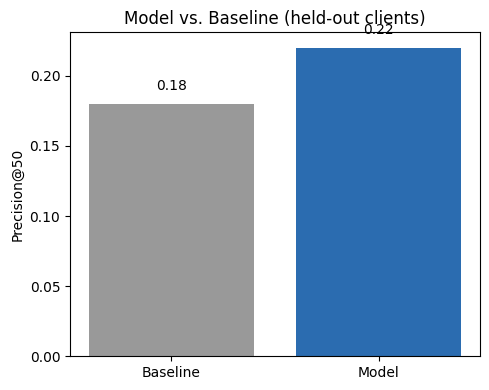

    model_score  impact_pct  search_volume  ctr_prev_30d     content_type  \
1      5.216667         0.0            0.0      0.000442  keyword article   
2      4.710000        -1.0            0.0      0.000446  keyword article   
3      3.660000        -1.0            0.0      0.000278  keyword article   
4      3.218333        -0.5            0.0      0.000549  keyword article   
5      2.865000         1.0            0.0      0.000669  keyword article   
6      2.858333         0.0            0.0      0.000661  keyword article   
7      2.615000        -1.0            0.0      0.000653  keyword article   
8      2.597833        -0.5            0.0      0.001195  keyword article   
9      2.543333         1.0            0.0      0.000397  keyword article   
10     2.101111         0.0            0.0      0.000989  keyword article   

                                            reason  
1   below-median CTR; content_type=keyword article  
2   below-median CTR; content_type=keyword art

In [14]:
import matplotlib.pyplot as plt

# --- Artifact 1: baseline vs model bar chart ---
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Baseline", "Model"], [baseline_p50, model_p50], color=["#999999", "#2b6cb0"])
ax.set_ylabel("Precision@50")
ax.set_title("Model vs. Baseline (held-out clients)")
for i, v in enumerate([baseline_p50, model_p50]):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.savefig("baseline_vs_model.png", dpi=150)
plt.show()

# --- Artifact 2: sample of the ranked queue (already saved as refresh_queue_sample.csv in Section 6) ---
print(recommendations.head(10))


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.